# MENS ONLY - Match Prediction

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd()
ADD_DIR = DATA_DIR.parent / "Additional"

matches = pd.read_parquet(DATA_DIR / "matches.parquet")
reg = pd.read_parquet(ADD_DIR / "for_regression.parquet")

# filter to men's only
matches = matches[matches['gender'] == 'male'].copy()
reg = reg[reg['OFF_MEN_WOMEN'] == 'M'].copy()

print(f"Matches: {matches.shape}")
print(f"Regression file: {reg.shape}")

Matches: (2924, 36)
Regression file: (538044, 39)


In [2]:
# aggregate xG by match and team
match_xg = reg.groupby(['match_id', 'OFF_TEAM_ID']).agg(
    total_xg=('total_xg', 'sum'),
    total_shots=('n_shots', 'sum')
).reset_index()

teams_per_match = match_xg.groupby('match_id')['OFF_TEAM_ID'].count()
print(f"Matches with exactly 2 teams: {(teams_per_match == 2).sum()}")
print(f"Matches with != 2 teams: {(teams_per_match != 2).sum()}")

# build match level with correct home/away alignment
match_meta = matches[['match_id', 'home_team_id', 'away_team_id', 'home_score', 'away_score']].copy()

match_xg_home = match_xg.merge(match_meta, left_on=['match_id', 'OFF_TEAM_ID'], 
                                right_on=['match_id', 'home_team_id'], how='inner')
match_xg_away = match_xg.merge(match_meta, left_on=['match_id', 'OFF_TEAM_ID'], 
                                right_on=['match_id', 'away_team_id'], how='inner')

match_xg_home = match_xg_home[['match_id', 'total_xg', 'total_shots', 'home_score', 'away_score']].rename(
    columns={'total_xg': 'home_xg', 'total_shots': 'home_shots'})
match_xg_away = match_xg_away[['match_id', 'total_xg', 'total_shots']].rename(
    columns={'total_xg': 'away_xg', 'total_shots': 'away_shots'})

match_final = match_xg_home.merge(match_xg_away, on='match_id')
match_final['xg_diff'] = match_final['home_xg'] - match_final['away_xg']
match_final['result'] = match_final.apply(lambda r:
    'home_win' if r['home_score'] > r['away_score']
    else 'away_win' if r['away_score'] > r['home_score']
    else 'draw', axis=1)

print(f"\nShape: {match_final.shape}")
print(f"Nulls: {match_final.isnull().sum().sum()}")
print(f"\nResult distribution:")
print(match_final['result'].value_counts())
print(f"\nMean xG diff by result:")
print(match_final.groupby('result')['xg_diff'].mean().sort_values(ascending=False))

Matches with exactly 2 teams: 2908
Matches with != 2 teams: 12

Shape: (2908, 9)
Nulls: 0

Result distribution:
result
home_win    1301
away_win     903
draw         704
Name: count, dtype: int64

Mean xG diff by result:
result
home_win    0.958468
draw        0.208849
away_win   -0.599558
Name: xg_diff, dtype: float64


In [3]:
X = match_final[['xg_diff']].values
y = match_final['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
print(f"\nCV Accuracy scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

              precision    recall  f1-score   support

    away_win       0.50      0.59      0.54       181
        draw       0.00      0.00      0.00       141
    home_win       0.56      0.80      0.66       260

    accuracy                           0.54       582
   macro avg       0.36      0.47      0.40       582
weighted avg       0.41      0.54      0.47       582


CV Accuracy scores: [0.58075601 0.58075601 0.59793814 0.57314974 0.58003442]
Mean: 0.5825 (+/- 0.0082)


In [4]:
result_map = {'away_win': 0, 'draw': 1, 'home_win': 2}
y_sm = match_final['result'].map(result_map)
X_sm = sm.add_constant(match_final[['xg_diff']])

mnlogit = sm.MNLogit(y_sm, X_sm)
result_mn = mnlogit.fit()
print(result_mn.summary())

Optimization terminated successfully.
         Current function value: 0.901425
         Iterations 6
                          MNLogit Regression Results                          
Dep. Variable:                 result   No. Observations:                 2908
Model:                        MNLogit   Df Residuals:                     2904
Method:                           MLE   Df Model:                            2
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.1547
Time:                        22:28:27   Log-Likelihood:                -2621.3
converged:                       True   LL-Null:                       -3101.1
Covariance Type:            nonrobust   LLR p-value:                4.508e-209
  result=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1057      0.054     -1.940      0.052      -0.212       0.001
xg_diff        0.7541      0.

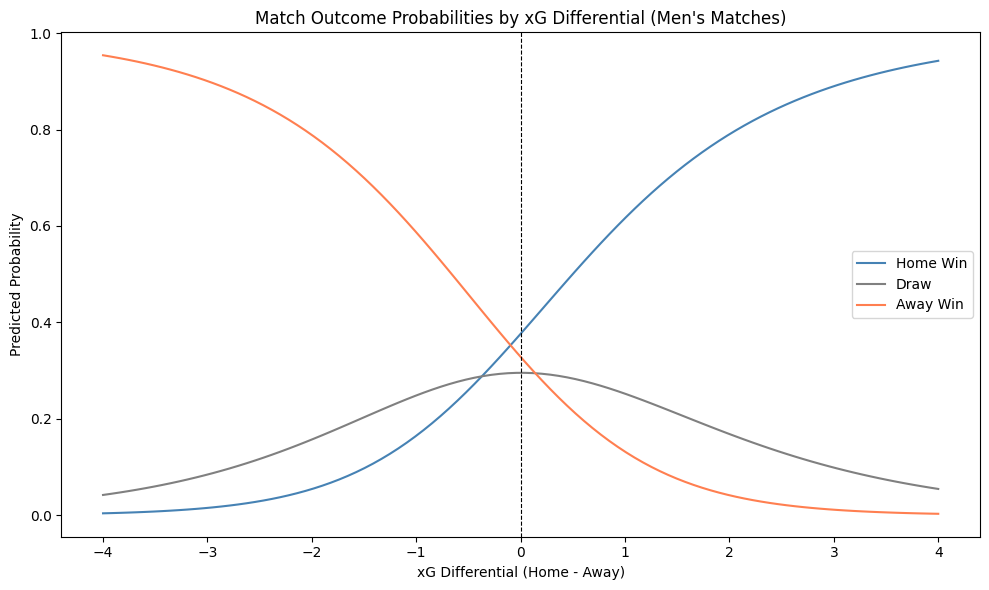

In [5]:
xg_range = np.linspace(-4, 4, 100)
X_plot = sm.add_constant(pd.DataFrame({'xg_diff': xg_range}))
probs = result_mn.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.plot(xg_range, probs[2], label='Home Win', color='steelblue')
plt.plot(xg_range, probs[1], label='Draw', color='gray')
plt.plot(xg_range, probs[0], label='Away Win', color='coral')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('xG Differential (Home - Away)')
plt.ylabel('Predicted Probability')
plt.title('Match Outcome Probabilities by xG Differential (Men\'s Matches)')
plt.legend()
plt.tight_layout()
plt.show()

**Summary: Multinomial logistic regression predicting match outcome (home win / draw / away win) from actual xG differential (home team xG minus away team xG), fitted on men's matches only (n = 2,908 matches).**

Highlights:

* xG differential is a strong predictor of men's match outcomes, w/ a pseudo R^2 of 0.155 w/ a single feature, highly significant (p ~ 0)
* @ xG differential of 0, the predicted probs are approx. 35% home win, 30% draw, 35% away win.
* A +1 xG differential in favor of the home team increases home win log-odds by 1.406 relative to away win

Model performance stats:

* 54% accuracy on test set, CV mean of 0.583 (std 0.008). This is fairly stable and consistent.
* Naive baseline of always predicting home win would yield around a 45% accuracy, so the model does add some predictive value

Notes:

* This model uses actual observed xG. Next step is replacing observed xG with predicted xG from our possession-level regression models to build lineup-based predictions
* Home/away team alignment was verified using the StatsBomb matches.parquet file
* 12 matches with incomplete lineup data were excluded, leaving 2,908 of 2,920 matched matches (very small percentage)
* Coefficients are nearly identical to the full dataset model.  This means that the men's-only results are still robust